In [2]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from datetime import date

In [3]:
data_path = "/Users/sabrinaderwent/Desktop/fall25/stat390/CAR_datasets/"
#adhoc_data_path = 'C:\\Users\\akl0407\\OneDrive - Northwestern University\\Back up\\2025-26\\Fall 2025\\LegalAid\\Adhoc\\Adhoc datasets\\'

In [4]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [5]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

In [6]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour
df_main.sort_values(by = ['Contact Session ID', 'Activity Start Timestamp'], inplace=True)
df_main.reset_index(inplace = True, drop = True)

In [7]:
def custdata(id):
    return df_main.loc[df_main['Contact Session ID'] == id,:]
def act_rows(act):
    return df_main.loc[df_main['Activity Name'] == act,:]
def act_data(act):
    get_act_rows = act_rows(act)
    return df_main.loc[df_main['Contact Session ID'].isin(get_act_rows['Contact Session ID']),:]
def data_rows(act, data):
    return data.loc[data['Activity Name'] == act,:]
def col_data(col, val):
    get_col_rows = df_main.loc[df_main[col] == val,:]
    return df_main.loc[df_main['Contact Session ID'].isin(get_col_rows['Contact Session ID']),:]
def col_rows(col, val):
    return df_main.loc[df_main[col] == val,:]
def calls_for_activity(act_name):
    return df_main.loc[df_main['Activity Name'] == act_name,'Contact Session ID'].nunique()
def tagging(data):     
    ids_already_present = data.loc[data['Contact Session ID'].isin(all_data['Contact Session ID']),'Contact Session ID'].nunique()
    print("IDs already present in the previously tagged data = ", ids_already_present)
    data = data.loc[~data['Contact Session ID'].isin(all_data['Contact Session ID']),:]
    print("IDs added = ", data['Contact Session ID'].nunique())    
    print("% IDs added = ", round(100*data['Contact Session ID'].nunique()/248422),"%")
    print("IDs per weekday = ", round(data['Contact Session ID'].nunique()/370))
    appended_data = pd.concat([all_data, data])
    print("IDs in tagged data = ", appended_data['Contact Session ID'].nunique())
    print("% data tagged = ", round(100*appended_data['Contact Session ID'].nunique()/248422),"%")
    return appended_data

In [8]:
df_main_copy = df_main.copy()
df_main_copy = df_main_copy.loc[~df_main['Activity Name'].isna(),:]

#### Main-menu only

In [9]:
num_EPs = df_main.groupby('Contact Session ID')['EP Name'].nunique()
one_ep_data = df_main.loc[df_main['Contact Session ID'].isin(num_EPs[num_EPs == 1].index),:]
main_menu_rows = one_ep_data.loc[one_ep_data['EP Name'] == 'Main Number Telephony EP',:]
main_menu_data = df_main.loc[df_main['Contact Session ID'].isin(main_menu_rows['Contact Session ID']),:]

num_acts = df_main.groupby('Contact Session ID')['Activity Name'].nunique()
no_acts_rem = df_main.loc[(df_main['Contact Session ID'].isin(num_acts[(num_acts == 0)].index)) & \
(df_main['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP'),:]
no_acts_rem_data = df_main.loc[df_main['Contact Session ID'].isin(no_acts_rem['Contact Session ID']),:]

main_menu_data = pd.concat([main_menu_data, no_acts_rem_data])
main_menu_data['caller_type'] = 'Main menu only'
print("% data = ", round(100*98352/248422),"%")
print("calls per day = ", round(98352/370))
print("calls per day = ",main_menu_data['Contact Session ID'].nunique())

% data =  40 %
calls per day =  266
calls per day =  98357


## closed hours

In [10]:
closed_hours_data = col_data('EP Name', 'Closed Hours-Holidays Menu Telephony EP')
closed_hours_data['caller_type'] = 'Closed hours callers'
print(closed_hours_data['Contact Session ID'].nunique())

ids1 = set(main_menu_data["Contact Session ID"])
ids2 = set(closed_hours_data["Contact Session ID"])
common_12 = ids1 & ids2
if len(common_12) == 0:
    print("No overlap with the previously tagged data")

all_data = pd.concat([main_menu_data,closed_hours_data])
print("% data = ", round(100*closed_hours_data['Contact Session ID'].nunique()/248422),"%")
print("calls per day = ", round(closed_hours_data['Contact Session ID'].nunique()/370))
all_data['Contact Session ID'].nunique()

21861
No overlap with the previously tagged data
% data =  9 %
calls per day =  59


120218

### Farmworker data
calls already tagged as during closed hours excluded
Removing farmworker data from analysis due to high abandonment rate

In [11]:
farm_data = act_data('FarmworkerMainMenu')
farmworker_rows = one_ep_data.loc[one_ep_data['EP Name'] == 'Farmworker Main Number Telephony EP',:]
farmworker_data = df_main.loc[df_main['Contact Session ID'].isin(farmworker_rows['Contact Session ID']),:]
more_farm_data = farmworker_data.loc[~farmworker_data['Contact Session ID'].isin(farm_data['Contact Session ID']),:]
farm_data = pd.concat([farm_data, more_farm_data])
farm_data['caller_type'] = 'Farmworker'
all_data = tagging(farm_data)

IDs already present in the previously tagged data =  90
IDs added =  10310
% IDs added =  4 %
IDs per weekday =  28
IDs in tagged data =  130528
% data tagged =  53 %


### Non-seniors legal menu
Calls that reach LegalMenu2, but never reach SuburbsOrCityMenu

In [12]:
legmen2_data = act_data('LegalMenu1')
leg_senior_data_rows = data_rows('SuburbsOrCityMenu',legmen2_data)
#Non-seniors never reach the suburbs or city menu
leg_non_senior_data = legmen2_data.loc[~legmen2_data['Contact Session ID'].isin(leg_senior_data_rows['Contact Session ID']),:]
leg_non_senior_data['caller_type'] = 'Non-senior legal issue'
all_data = tagging(leg_non_senior_data)

IDs already present in the previously tagged data =  581
IDs added =  79085
% IDs added =  32 %
IDs per weekday =  214
IDs in tagged data =  209613
% data tagged =  84 %


## Seniors
### Suburban seniors
Calls that reach SuburbanSeniorsMenu menu

In [13]:
suburban_seniors_data = act_data('SuburbanSeniorsMenu')
suburban_seniors_data['caller_type'] = 'Suburban senior'
all_data = tagging(suburban_seniors_data)

IDs already present in the previously tagged data =  14
IDs added =  8305
% IDs added =  3 %
IDs per weekday =  22
IDs in tagged data =  217918
% data tagged =  88 %


### City Seniors

In [14]:
city_seniors = act_data('SeniorsADAPTMenu')
city_seniors['caller_type'] = 'Chicago senior'
all_data = tagging(city_seniors)

IDs already present in the previously tagged data =  55
IDs added =  17975
% IDs added =  7 %
IDs per weekday =  49
IDs in tagged data =  235893
% data tagged =  95 %


### Non cook county seniors

In [15]:
noncook_seniors = act_data('SeniorNotCookCoMenu')
noncook_seniors['caller_type'] = 'Non-Cook County Senior'
all_data = tagging(noncook_seniors)

IDs already present in the previously tagged data =  10
IDs added =  1302
% IDs added =  1 %
IDs per weekday =  4
IDs in tagged data =  237195
% data tagged =  95 %



### Unclassified seniors

In [16]:
#unclassified_seniors = act_data('SuburbsOrCityMenu')
#unclassified_seniors['caller_type'] = 'Unclassified seniors'
#all_data = tagging(unclassified_seniors)

All these seniors abandoned call before making a choice

## Intake outdial EP

In [17]:
intake_rows = one_ep_data.loc[one_ep_data['EP Name'] == 'Intake Outdial EP',:]
intake_outdial_data = df_main.loc[df_main['Contact Session ID'].isin(intake_rows['Contact Session ID']),:]
intake_outdial_data['caller_type'] = 'Intake Outdial'
all_data = tagging(intake_outdial_data)

IDs already present in the previously tagged data =  0
IDs added =  9395
% IDs added =  4 %
IDs per weekday =  25
IDs in tagged data =  246590
% data tagged =  99 %


### Rest

In [18]:
rest_data = df_main.loc[~df_main['Contact Session ID'].isin(all_data['Contact Session ID']),:]
rest_data.shape

(16691, 9)

In [19]:
rest_data_nomissact = rest_data.loc[~rest_data['Activity Name'].isna(),:]
last_act = rest_data_nomissact.groupby('Contact Session ID').tail(1)[['Contact Session ID', 'Activity Name']]
rest_data_nomissact.groupby('Contact Session ID').tail(1)[['Activity Name']].value_counts()

Activity Name          
SeniorsMenu                1197
SuburbsOrCityMenu           443
SeniorsConfirmationMenu     211
MainMenu                      1
Name: count, dtype: int64

In [20]:
rest_data['caller_type'] = 'unclassified (with access to legal issues menu)'
all_data = tagging(rest_data)

IDs already present in the previously tagged data =  0
IDs added =  1852
% IDs added =  1 %
IDs per weekday =  5
IDs in tagged data =  248442
% data tagged =  100 %


All these calls are abandoned before information about the caller was obtained

### caller type summary

In [21]:
call_type = pd.DataFrame({'calls':all_data.groupby('caller_type')['Contact Session ID'].nunique().sort_values(ascending = False)})
call_type['percent_calls'] = round(100*call_type['calls'] / 248442)
call_type['calls_per_weekday'] = round(call_type['calls'] / 370)
call_type

,calls,percent_calls,calls_per_weekday
caller_type,,,
Main menu only,98357,40.0,266.0
Non-senior legal issue,79085,32.0,214.0
Closed hours callers,21861,9.0,59.0
Chicago senior,17975,7.0,49.0
Farmworker,10310,4.0,28.0
Intake Outdial,9395,4.0,25.0
Suburban senior,8305,3.0,22.0
unclassified (with access to legal issues menu),1852,1.0,5.0
Non-Cook County Senior,1302,1.0,4.0


In [22]:
all_data['Overall_tag'] = "Legal issue"
all_data.loc[all_data['caller_type'].isin(['Farmworker','Intake Outdial','Closed hours callers']),'Overall_tag'] = 'Other'
all_data.loc[all_data['caller_type'] == 'Main menu only','Overall_tag'] = 'Main menu'
call_type = pd.DataFrame({'calls':all_data.groupby('Overall_tag')['Contact Session ID'].nunique().sort_values(ascending = False)})
call_type['percent_calls'] = round(100*call_type['calls'] / 248442)
call_type['calls_per_weekday'] = round(call_type['calls'] / 370)
call_type

,calls,percent_calls,calls_per_weekday
Overall_tag,,,
Legal issue,108519,44.0,293.0
Main menu,98357,40.0,266.0
Other,41566,17.0,112.0


##  Outcome Tagging


In [42]:
outcomes = {
    'ClosedQueueMenu': 'Negative',
    'StaffDirectoryEnglishTransfer': 'Positive',
    'LanguageSelectionMenu': 'Negative',
    'MainMenu': 'Negative',
    'LegalMenu2': 'Negative',
    'FarmworkerMainMenu': 'Negative',
    'SetCallerID': 'Positive',
    'LegalServerScreenPop': 'Positive',
    'FrontDeskTransfer1': 'Neutral',
    'ClosedMenu': 'Neutral',
    'FrontDeskTransfer2': 'Positive',
    'StaffDirectorySpanishTransfer': 'Positive',
    'FrontDeskTransfer': 'Neutral',
    'TenantMenu': 'Negative',
    'CriminalRecordsVoicemailTransfer': 'Positive',
    'OtherLegalOtherMenu': 'Neutral',
    'DivorceOrParentingMenu': 'Negative',
    'QueueMenu1': 'Negative',
    'LegalMenu1': 'Negative',
    'SeniorsMenu': 'Negative',
    'TenantDeterrenceMenu': 'Neutral',
    'HousingMenu': 'Negative',
    'HIVVoicemailTransfer': 'Positive',
    'PlayMOH300s': 'Negative',
    'HIVMenu': 'Negative',
    'ScreenPopProcessComplete': 'Positive',
    'AddressFaxHoursMenu': 'Positive',
    'PreTenantMenu': 'Neutral',
    'FamilyMenu': 'Negative',
    'FrontDeskTransfer3': 'Neutral',
    'ChildSupportMenu': 'Neutral',
    'ImmigrationMenu': 'Negative',
    'SeniorsADAPTMenu': 'Negative',
    'OtherLegalPersonalInjuryMenu': 'Neutral',
    'OtherLegalCriminalCaseMenu': 'Neutral',
    'SuburbsOrCityMenu': 'Negative',
    'SuburbanSeniorsMenu': 'Negative',
    'TransferToSafeHaven': 'Positive',
    'SimpleDivorceMenu': 'Neutral',
    'BenefitsMenu': 'Negative',
    'SubSeniorPreQueueMessage1_1': 'Negative',
    'ThankYouGoodbye': 'Neutral',
    'IntakePreQueueMessage1': 'Negative',
    'SeniorsConfirmationMenu': 'Negative',
    'VeteransBenefitsVoicemailTransfer': 'Positive',
    'EmploymentMenu': 'Negative',
    'No activity': 'Negative',
    'DisconnectContact2': 'Neutral',
    'SubSeniorConsumerQueue': 'Negative',
    'SubSeniorHomeownerQueue': 'Negative',
    'PlayCCBConfirmation': 'Negative',
    'EducationSPQueue': 'Negative',
    'SubSeniorTenantQueue': 'Negative',
    'ImmigrationSPQueue': 'Negative',
    'SubSeniorOtherQueue': 'Negative',
    'SubSeniorPreQueueMessage1_2': 'Negative',
    'ConfirmCallbackNumber': 'Negative',
    'CollectCallbackNumber': 'Negative',
    'CallbackRetry': 'Negative',
    'PlayErrorMessage': 'Negative',
    'ReadANI': 'Negative',
    'GetLoggedInSubSeniorTenantAgents': 'Negative',
    'WorkersCompMenu': 'Neutral',
    'DisconnectContact': 'Negative',
    'HelpWithLegalorOtherReasonMenu': 'Negative',
    'PreQueueMessage2': 'Negative',
    'ComplimentOrComplaintMenu': 'Positive',
    'MigrantVoicemailTransfer': 'Positive',
    'DisconnectCallbackContact': 'Negative',
    'HolidayPrompt': 'Neutral',
    'ImmigrationOtherMenu': 'Neutral',
    'SeniorNotCookCoMenu': 'Neutral',
    'AppointmentMenu': 'Negative',
    'TraffickingVoicemailTransfer': 'Positive',
    'GetLoggedInSubSeniorTenantSPAgents': 'Negative', 
    'GetLoggedInOtherSubSeniorsAgents' : 'Negative', 
    'GetLoggedInConsumerAgents': 'Negative', 
    'GetLoggedInSubSeniorOtherSPAgents': 'Negative', 
    'GetLoggedInSubSeniorOtherAgents' : 'Negative'
    
}


In [43]:
subtypes = {
    'ClosedQueueMenu': 'Closed Queue',
    'StaffDirectoryEnglishTransfer': 'Staff Directory',
    'LanguageSelectionMenu': 'Abandoned',
    'MainMenu': 'Abandoned',
    'LegalMenu2': 'Abandoned',
    'FarmworkerMainMenu': 'Abandoned',
    'SetCallerID': 'Connected to agent',
    'LegalServerScreenPop': 'Connected to agent',
    'FrontDeskTransfer1': 'No language selected (FD1)',
    'ClosedMenu': 'Closed Hours',
    'FrontDeskTransfer2': 'Feedback',
    'StaffDirectorySpanishTransfer': 'Staff Directory',
    'FrontDeskTransfer': 'Interpreter needed (FD, Legal menu)',
    'TenantMenu': 'Abandoned',
    'CriminalRecordsVoicemailTransfer': 'Reached Voicemail',
    'OtherLegalOtherMenu': 'LAC does not serve',
    'DivorceOrParentingMenu': 'Abandoned',
    'QueueMenu1': 'Abandoned',
    'LegalMenu1': 'Abandoned',
    'SeniorsMenu': 'Abandoned',
    'TenantDeterrenceMenu': 'LAC does not serve',
    'HousingMenu': 'Abandoned',
    'HIVVoicemailTransfer': 'Reached Voicemail',
    'PlayMOH300s': 'Abandoned',
    'HIVMenu': 'Abandoned',
    'ScreenPopProcessComplete': 'Connected to agent',
    'AddressFaxHoursMenu': 'Reached Voicemail',
    'PreTenantMenu': 'LAC does not serve',
    'FamilyMenu': 'Abandoned',
    'FrontDeskTransfer3': 'No selection on Main menu (FD3)',
    'ChildSupportMenu': 'LAC does not serve',
    'ImmigrationMenu': 'Abandoned',
    'SeniorsADAPTMenu': 'Abandoned',
    'OtherLegalPersonalInjuryMenu': 'LAC does not serve',
    'OtherLegalCriminalCaseMenu': 'LAC does not serve',
    'SuburbsOrCityMenu': 'Abandoned',
    'SuburbanSeniorsMenu': 'Abandoned',
    'TransferToSafeHaven': 'Chatbot experiment (Family menu)',
    'SimpleDivorceMenu': 'LAC does not serve',
    'BenefitsMenu': 'Abandoned',
    'SubSeniorPreQueueMessage1_1': 'Abandoned',
    'ThankYouGoodbye': 'LAC does not serve',
    'IntakePreQueueMessage1': 'Abandoned',
    'SeniorsConfirmationMenu': 'Abandoned',
    'VeteransBenefitsVoicemailTransfer': 'Reached Voicemail',
    'EmploymentMenu': 'Abandoned',
    'No activity': 'Abandoned',
    'DisconnectContact2': 'LAC does not serve',
    'SubSeniorConsumerQueue': 'Abandoned',
    'SubSeniorHomeownerQueue': 'Abandoned',
    'PlayCCBConfirmation': 'Failed Courtesy Callback',
    'EducationSPQueue': 'Abandoned',
    'SubSeniorTenantQueue': 'Abandoned',
    'ImmigrationSPQueue': 'Abandoned',
    'SubSeniorOtherQueue': 'Abandoned',
    'SubSeniorPreQueueMessage1_2': 'Abandoned',
    'ConfirmCallbackNumber': 'Abandoned',
    'CollectCallbackNumber': 'Abandoned',
    'CallbackRetry': 'Failed Courtesy Callback',
    'PlayErrorMessage': 'Abandoned',
    'ReadANI': 'Failed Courtesy Callback',
    'GetLoggedInSubSeniorTenantAgents': 'Abandoned',
    'WorkersCompMenu': 'LAC does not serve',
    'DisconnectContact': 'Outbound Call Failed',
    'HelpWithLegalorOtherReasonMenu': 'Abandoned',
    'PreQueueMessage2': 'Abandoned',
    'ComplimentOrComplaintMenu': 'Feedback',
    'MigrantVoicemailTransfer': 'Reached Voicemail',
    'DisconnectCallbackContact': 'Failed Courtesy Callback',
    'HolidayPrompt': 'Closed Hours',
    'ImmigrationOtherMenu': 'LAC does not serve',
    'SeniorNotCookCoMenu': 'LAC does not serve',
    'AppointmentMenu': 'Abandoned',
    'TraffickingVoicemailTransfer': 'Reached Voicemail',
    'GetLoggedInSubSeniorTenantSPAgents': 'Abandoned', 
'GetLoggedInOtherSubSeniorsAgents' : 'Abandoned', 
'GetLoggedInConsumerAgents': 'Abandoned', 
'GetLoggedInSubSeniorOtherSPAgents': 'Abandoned', 
'GetLoggedInSubSeniorOtherAgents' : 'Abandoned'
}

In [44]:
all_data['LastActivity'] = all_data.groupby('Contact Session ID')['Activity Name'].transform('last')
all_data['OutcomeTag'] = all_data['LastActivity'].map(outcomes)
all_data['SubtypeTag'] = all_data['LastActivity'].map(subtypes)
all_data.groupby('Contact Session ID').nunique()

,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour,caller_type,Overall_tag,LastActivity,OutcomeTag,SubtypeTag
Contact Session ID,,,,,,,,,,,,,
00002422-f51f-458b-82d6-cfa5a3f36fd9,1,1,3,4,1,1,0,1,1,1,1,1,1
0000a8d5-cecb-46b1-82cf-b7ce07d85b24,2,2,3,5,0,0,1,1,1,1,1,1,1
00011655-35de-476f-9a8c-dd48ed4d914a,1,1,4,10,1,1,0,1,1,1,1,1,1
00014a58-a6ce-4cb2-a529-d55e2c9c304d,5,6,7,8,0,0,0,1,1,1,1,1,1
00015327-f646-462f-a585-0552331eed4e,2,2,3,3,0,0,1,1,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffe199f-3382-43e1-b8a5-efb9d55bdb23,1,1,2,3,0,0,0,2,1,1,1,1,1
fffe91b1-c54d-4b1e-b19d-1ef78e4a8871,1,1,2,5,1,1,0,1,1,1,1,1,1
fffed0e4-d57d-42dc-8d9e-725ce451fa9e,5,6,8,10,0,0,1,1,1,1,1,1,1


In [45]:
outcomes = all_data.groupby('Contact Session ID').last().groupby(['caller_type', 'OutcomeTag']).size().unstack(fill_value=0)
outcomes

OutcomeTag,Negative,Neutral,Positive
caller_type,,,
Chicago senior,9689,1091,1758
Closed hours callers,135,7850,3153
Farmworker,10094,38,101
Intake Outdial,32,0,9358
Main menu only,40459,8430,36375
Non-Cook County Senior,295,399,51
Non-senior legal issue,49902,6828,8184
Suburban senior,3775,286,3536
unclassified (with access to legal issues menu),1852,0,0


In [47]:
all_data['OutcomeTag'].isnull().sum()

np.int64(661007)

There are calls that are being missed in the outcome tagging - this is why my numbers are different than Krish.


In [34]:
subtypes = all_data.groupby('Contact Session ID').last().groupby(['caller_type', 'SubtypeTag']).size().unstack(fill_value=0)
subtypes

SubtypeTag,Abandoned,Chatbot experiment (Family menu),Closed Hours,Closed Queue,Connected to agent,Failed Courtesy Callback,Feedback,"Interpreter needed (FD, Legal menu)",LAC does not serve,No language selected (FD1),No selection on Main menu (FD3),Outbound Call Failed,Reached Voicemail,Staff Directory
caller_type,,,,,,,,,,,,,,
Chicago senior,3662,20,0,6013,1253,13,6,246,845,0,0,0,459,20
Closed hours callers,135,0,7850,0,0,0,0,0,0,0,0,0,518,2635
Farmworker,9895,0,0,199,22,0,0,19,19,0,0,0,79,0
Intake Outdial,0,0,0,0,9358,0,0,0,0,0,0,32,0,0
Main menu only,40459,0,0,0,0,0,6927,0,0,7890,540,0,153,29295
Non-Cook County Senior,104,1,0,190,22,1,0,7,392,0,0,0,28,0
Non-senior legal issue,18084,391,0,31755,4800,63,20,2273,4554,0,1,0,2929,44
Suburban senior,1994,0,0,1735,3536,34,0,0,286,0,0,0,0,0
unclassified (with access to legal issues menu),1852,0,0,0,0,0,0,0,0,0,0,0,0,0


## Graphs

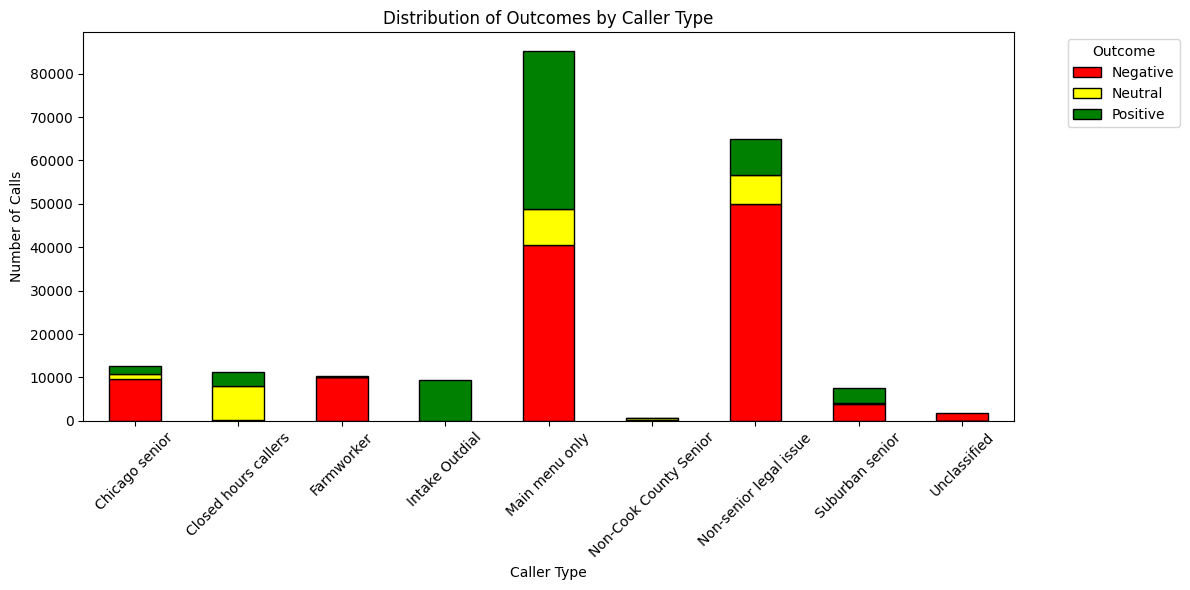

In [ ]:
outcomes = outcomes.rename(index={"unclassified (with access to legal issues menu)": "Unclassified"})
colors = ['red','yellow','green']

ax = outcomes.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color = colors,
    edgecolor='black'
)

ax.set_ylabel('Number of Calls')
ax.set_xlabel('Caller Type')
ax.set_title('Distribution of Outcomes by Caller Type')
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

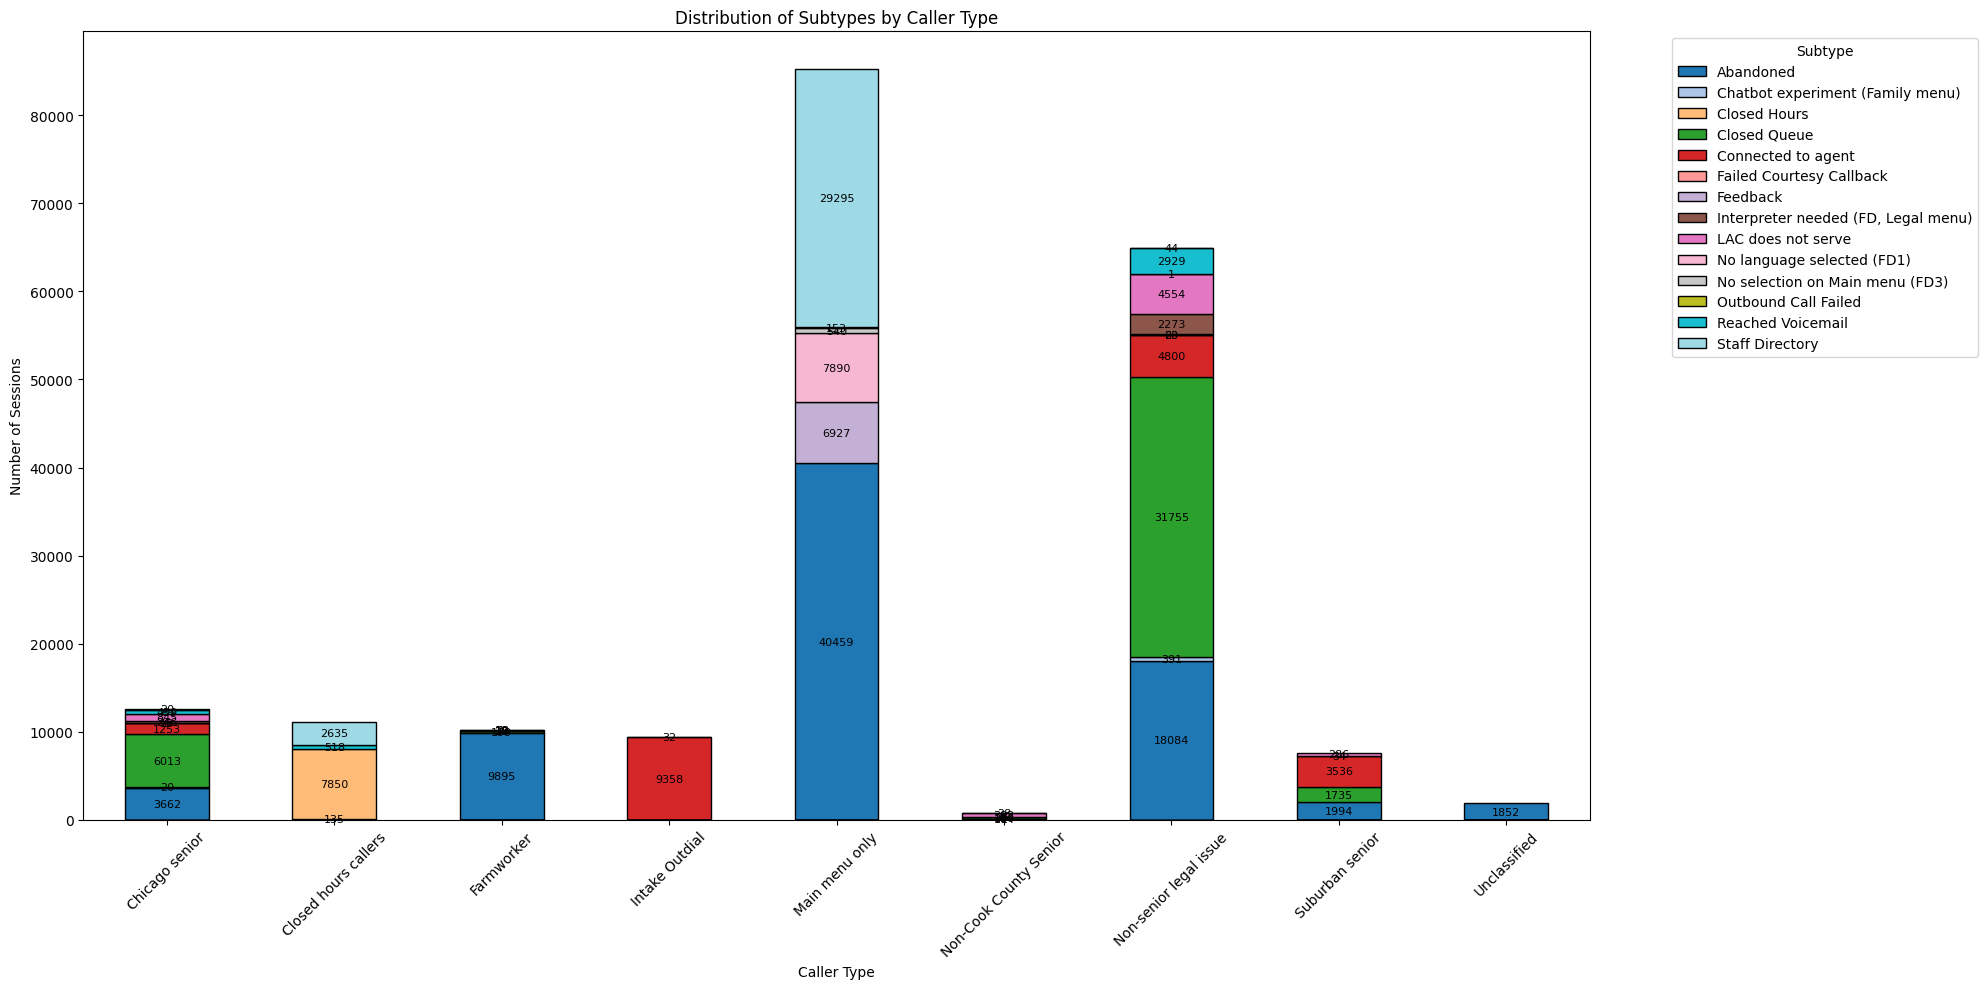

In [ ]:
import matplotlib.pyplot as plt

subtypes = subtypes.rename(index={"unclassified (with access to legal issues menu)": "Unclassified"})

ax = subtypes.plot(
    kind='bar',
    stacked=True,
    figsize=(20, 10),
    colormap = 'tab20',
    edgecolor='black'
)

ax.set_ylabel('Number of Sessions')
ax.set_xlabel('Caller Type')
ax.set_title('Distribution of Subtypes by Caller Type')
ax.legend(title='Subtype', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + width / 2, p.get_y() + height / 2),
                    ha='center', va='center', fontsize=8, color='black')

plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()
